[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/25%20-%20Spearman%20Rank%20Correlation%20and%20Chi-Square%20Test/Spearman_Rank_Correlation_and_Chi_Square_Test.ipynb)

# Overview

Spearman's Rank is used to find the correlation between **categorical, non-linearly related and non-normally distributed variables**.


When computing **Spearman's Rank Correlation**, we have to ensure the following:

a) The variables/attributes are numeric and able to be bucketed into categories

b) The variables are related non-lineraly

c) The variables are non-normally distibuted


**Chi-Square test:**

Standard statistical test to estimate the probability if the correlation is purely the result of chance (called the *null hypothesis*). If this probability (called the p-value) is higher than a given threshold (typically 5%), then the *null hypothesis* is accepted, else rejected

* If the p-value is < 0.05 then you reject the *null hypothesis* and conclude that the variables are **correlated**

* If the p-value is > 0.05 then you accept the *null hypothesis* and conclude that the variables are **independent**


# Data

Cars dataset: https://www.dropbox.com/s/h4zwkqzkq6o90tk/mtcars.csv?raw=1

We will focus on `cyl` v/s `am`, `gear` and `carb`


In [0]:
!wget https://www.dropbox.com/s/h4zwkqzkq6o90tk/mtcars.csv?raw=1 -nc -O cars.csv

--2018-11-12 21:59:55--  https://www.dropbox.com/s/h4zwkqzkq6o90tk/mtcars.csv?raw=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.1
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/raw/h4zwkqzkq6o90tk/mtcars.csv [following]
--2018-11-12 22:00:10--  https://www.dropbox.com/s/raw/h4zwkqzkq6o90tk/mtcars.csv
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb2ec362abc7220d8a920510b21.dl.dropboxusercontent.com/cd/0/inline/AVayWRVlSZnEVnpOjAmNBKMYgXC-diUEMgIL94X5GqHGc6Z63S7lNDRV4xesVQcUdRKOYWAJd7QriARnuJVdvS5xHyj1_pgW7Mp-XngVT326kUtbCCHZYKNu6xujv3-c1id0-8_RUtANZDWfwy6byd2_QY5GQQbNS9xoTZwIKsau72iHpSt-fYigFNMY8W7iRUg/file [following]
--2018-11-12 22:00:10--  https://ucb2ec362abc7220d8a920510b21.dl.dropboxusercontent.com/cd/0/inline/AVayWRVlSZnEVnpOjAmNBKMYgXC-diUEMgIL94X5GqHGc6Z63S7lNDRV4xesVQcUdRKOYWAJd7QriA

In [0]:
import pandas as pd
import numpy as np

df = pd.read_csv('cars.csv')
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


### Lets sort by `cyl` to better visualize our plots

In [0]:
data = df.copy()
data.sort_values(by=['cyl'], inplace=True)
data.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
31,Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.60,1,1,4,2
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1


# Visualize

In [0]:
cyl_data = data['cyl']
am_data = data['am']
gear_data = data['gear']
carb_data = data['carb']

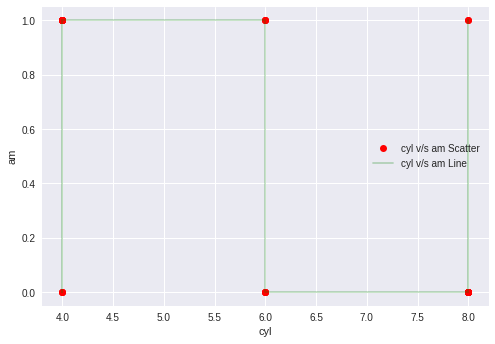

In [0]:
import matplotlib.pyplot as plt

plt.plot(cyl_data, am_data, 'or', label='cyl v/s am Scatter')
plt.plot(cyl_data, am_data, '-g', alpha=0.25, label='cyl v/s am Line')
plt.xlabel('cyl')
plt.ylabel('am')
plt.legend();

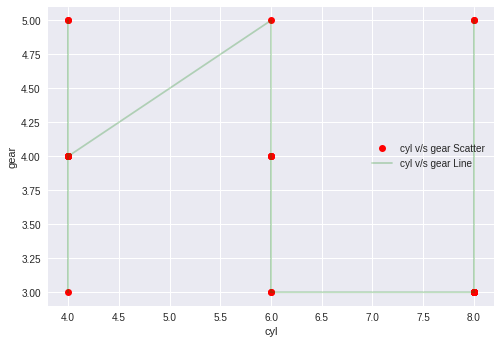

In [0]:
plt.plot(cyl_data, gear_data, 'or', label='cyl v/s gear Scatter')
plt.plot(cyl_data, gear_data, '-g', alpha=0.25, label='cyl v/s gear Line')
plt.xlabel('cyl')
plt.ylabel('gear')
plt.legend();

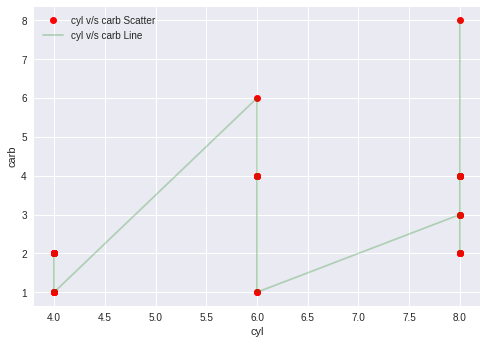

In [0]:
plt.plot(cyl_data, carb_data, 'or', label='cyl v/s carb Scatter')
plt.plot(cyl_data, carb_data, '-g', alpha=0.25, label='cyl v/s carb Line')
plt.xlabel('cyl')
plt.ylabel('carb')
plt.legend();

**Observation:** From the above scatter plots, it looks like all 3 conditions for the Spearman's Rank Correlation seem to be holding true

a) numeric variables that can be placed in categories

b) non-linearly related

c) non-normally distributed

# Spearman's Rank Correlation Coefficient

In [0]:
req_data = pd.DataFrame(data, columns=['cyl', 'am', 'gear', 'carb'])
req_data.head()

,cyl,am,gear,carb
31,4,1,4,2
2,4,1,4,1
27,4,1,5,2
26,4,1,5,2
25,4,1,4,1


In [0]:
req_data.corr(method='spearman')

,cyl,am,gear,carb
cyl,1.000000,-0.522071,-0.564310,0.580068
am,-0.522071,1.000000,0.807688,-0.064365
gear,-0.564310,0.807688,1.000000,0.114887
carb,0.580068,-0.064365,0.114887,1.000000


### Alternate way

In [0]:
cyl_data = df['cyl']
am_data = df['am']
gear_data = df['gear']
carb_data = df['carb']

In [0]:
import scipy.stats as stats

cor, pval = stats.spearmanr(cyl_data, am_data)
print(cor)
cor, pval = stats.spearmanr(cyl_data, gear_data)
print(cor)
cor, pval = stats.spearmanr(cyl_data, carb_data)
print(cor)

-0.5220711818077188
-0.5643104747017164
0.580067978775226


# Chi-Square test

In [0]:
import scipy.stats as stats

def chi_square_test(var1, var2):
  cross_data = pd.crosstab(data[var1], data[var2])
  chi2, p, dof, expected = stats.chi2_contingency(cross_data)
  return p

def print_pvalue(p, var1, var2):
  print("p-value for '%s' and '%s' = %s" % (var1, var2, str(p)))

In [0]:
p_value_threshold = 0.05

def print_independence(p, var1, var2):
  if (p < p_value_threshold):
    print("'%s' and '%s' are correlated" %(var1, var2))
  else:
    print("'%s' and '%s' are not correlated" %(var1, var2))  

In [0]:
var1 = 'cyl'
var2 = 'am'
p = chi_square_test(var1, var2)
print_pvalue(p, var1, var2)

print_independence(p, var1, var2)

p-value for 'cyl' and 'am' = 0.012646605046107276
'cyl' and 'am' are correlated


In [0]:
var1 = 'cyl'
var2 = 'gear'
p = chi_square_test(var1, var2)
print("p-value b/w %s and %s = %s" % (var1, var2, str(p)))

print_independence(p, var1, var2)

p-value b/w cyl and gear = 0.0012140660337851554
'cyl' and 'gear' are correlated


In [0]:
var1 = 'cyl'
var2 = 'carb'
p = chi_square_test(var1, var2)
print("p-value b/w %s and %s = %s" % (var1, var2, str(p)))

print_independence(p, var1, var2)

p-value b/w cyl and carb = 0.006632477762992059
'cyl' and 'carb' are correlated
